<a href="https://colab.research.google.com/github/macarenahulsken/connectatel-data-analysis/blob/main/ConnectaTel_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ConnectaTel Analysis

Objective: To evaluate **customer behavior and service usage patterns** for ConnectaTel, a Latin American telecommunications company.

Scope: The study utilizes data recorded through 2024, providing a comprehensive analysis of business performance and user trends within that specific period.

Datasets:

- **plans.csv** → Plan Details: Information on current offerings, including pricing, included minutes/data (GB), and overage costs.
- **users.csv** → Customer Profiles: Demographic and account data, including age, city, registration date, assigned plan, and churn status.
- **usage.csv** → Service Activity: Granular details of actual service usage, specifically tracking voice calls and text messaging.

---
## 🧩 Step 1: Data Loading and Exploration

In [188]:
# Importing Tools and Libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [189]:
# Datasets upload
base_url = 'https://raw.githubusercontent.com/macarenahulsken/connectatel-data-analysis/refs/heads/main/'

plans = pd.read_csv(base_url + 'plans.csv')
usage = pd.read_csv(base_url + 'usage.csv')
users = pd.read_csv(base_url + 'users_latam.csv')

In [190]:
plans.sample(2)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
1,Premium,500,20,600,25,1.0,0.05,0.07
0,Basico,100,5,100,12,1.2,0.08,0.10


In [191]:
users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
370,10370,Mateo,Lopez,77,Bogotá,2022-04-12 07:30:28.357089273,Basico,NaN
3674,13674,Mateo,Gomez,48,CDMX,2024-10-03 00:12:57.794448624,Premium,NaN
584,10584,Carlos,Gomez,43,Cali,2022-06-09 21:50:22.055513880,Premium,NaN
3979,13979,Luis,Lopez,73,NaN,2024-12-25 12:34:01.710427616,Basico,"1,73508E+18"
1769,11769,Ana,Gomez,19,CDMX,2023-04-30 09:14:10.712678168,Basico,NaN


In [192]:
usage.sample(5)

,id,user_id,type,date,duration,length
36527,36528,10026,text,2024-06-14 06:55:52.943823594,NaN,54.0
30714,30715,13137,call,2024-05-18 23:37:25.646141152,17.37,NaN
24966,24967,12659,text,2024-04-22 23:22:31.383784594,NaN,80.0
27256,27257,10626,call,2024-05-03 08:04:32.166804170,6.41,NaN
26394,26395,12965,text,2024-04-29 10:27:36.221405534,NaN,45.0


### 1.2 Exploración de la estructura de los datasets

In [193]:
# Check dataset shape (rows/columns)
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [194]:
# Data Quality Assessment: Types, Nulls, and Inconsistencies
print('')
print(f"Info plans:")
print("-" * 50)
plans.info()

print()
print('Info users:')
print('-' * 50)
users.info()

print()
print('Info usage:')
print('-' * 50)
usage.info()


Info plans:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes

Info users:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 

---

## 🧩Step 2: Data Quality Assessment

### Missing Values Analysis

**🎯 Objetive:**  
Detect the presence and scale of missing values to determine if they impact the analysis or require imputation/removal.

The plans dataset contains only 2 rows and shows no missing values; therefore, no further exploration is required.

In [195]:
# Missing values in 'users' dataset
print('Missing values:')
print(users.isnull().sum().sort_values(ascending=False))
print()
print('Percentage of missing values')
print((users.isnull().mean().sort_values(ascending=False))*100)

Missing values:
churn_date    3534
city           469
user_id          0
first_name       0
age              0
last_name        0
reg_date         0
plan             0
dtype: int64

Percentage of missing values
churn_date    88.350
city          11.725
user_id        0.000
first_name     0.000
age            0.000
last_name      0.000
reg_date       0.000
plan           0.000
dtype: float64


In [196]:
# Missing values in 'usage' dataset
print('Missing values:')
print(usage.isnull().sum().sort_values(ascending=False))
print()
print('Percentage of missing values:')
print((usage.isnull().mean().sort_values(ascending=False))*100)

Missing values:
duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64

Percentage of missing values:
duration    55.190
length      44.740
date         0.125
id           0.000
user_id      0.000
type         0.000
dtype: float64


**Missing Values**

**Users:** The city column has 11.7% missing values, which requires further investigation to identify potential patterns or root causes. The churn_date column shows 88.3% missing values; these will be ignored as they are not significant for the current scope of analysis.
**Usage:** Shows 55% missing values in duration and 45% in length. The reason for these gaps must be investigated to determine if the data is missing at random. The date column has a negligible 0.12% missing rate, which will be analyzed to decide on the best imputation strategy.

### 2.2 Sentinel and Invalid Value Detection

🎯 **Objetive:**  
Identify sentinels (placeholders) and invalid values that should not be present in the dataset.

The plans dataset contains only 2 rows; therefore, no further exploration is required.

In [197]:
users.info()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


- The `user_id` column assigns a unique identifier to each user.
- The `city` column contains '?' values, which act as missing indicators and need to be replaced.
- The `age` column is complete but contains '-999' values, which are placeholders that must be handled/replaced.

In [198]:
num_cols = ['duration', 'length', 'id', 'user_id']
usage[num_cols].describe()

,duration,length,id,user_id
count,17924.000000,22104.000000,40000.00000,40000.000000
mean,5.202237,52.127398,20000.50000,12002.405975
std,6.842701,56.611183,11547.14972,1157.279564
min,0.000000,0.000000,1.00000,10000.000000
25%,1.437500,37.000000,10000.75000,10996.000000
50%,3.500000,50.000000,20000.50000,12013.000000
75%,6.990000,64.000000,30000.25000,13005.000000
max,120.000000,1490.000000,40000.00000,13999.000000


- The `id` and `user_id` columns establish a relationship between individual users and their specific transaction records.
- In the `duration` and `length` columns, outliers (extreme values) have been detected, which require further investigation to ensure data integrity.

In [199]:
# Categorical analysis: User profile
user_columns = ['city', 'plan']
users[user_columns].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- The `city` column reveals that Bogota is the leading market among the seven cities where the service is available.
- The plan column includes two types of plans, with the Basic (or Standard) `plan` being the predominant choice among users.

In [200]:
# Categorical Analysis: Usage Dataset
usage['type'].describe()

,type
count,40000
unique,2
top,text
freq,22092


- The type column contains two unique values. Based on previous documentation, we know these represent 'text' and 'call', with 'text' being the most frequent category.

---
**Invalid Values and Sentinels**

- Potential outliers have been observed in the `duration` and `length` columns.

Action Plan:
- A formal outlier detection process will be performed on these columns. Based on the results, a specific treatment strategy (such as trimming or winsorization) will be determined and applied.

### 2.3 Date Review and Standardization

**🎯 Objective:**
Ensure all date columns are correctly formatted and detect out-of-range years that may indicate data entry errors.

In [201]:
# Converting `reg_date` column to datetime format
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [202]:
# Convert `date` column to datetime format
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [203]:
# Checking for unique years in `reg_date`

users['year'] = users['reg_date'].dt.year
sorted(users['year'].unique())

[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2026)]

An analysis of reg_date reveals a range of valid years; however, an anomaly was detected: the year 2026 is present, which is an impossible value (out-of-range) and indicates a possible data entry error.

In [204]:
# Checking for unique years in de `usage`
usage['year'] = usage['date'].dt.year
sorted(usage['year'].unique())

[np.float64(2024.0), np.float64(nan)]

Imputation Strategy for `date` in usage:
The `date` column contains 50 missing values. Since the context of the dataset is specific to 2024, these nulls will be imputed with that year. Given that these records represent only a tiny fraction of the data, this replacement will not significantly skew the overall statistics or the integrity of the analysis.

** Out-of-Range Dates**
- An impossible year (2026) was identified in reg_date, along with years that are outside the scope of this study (2022 and 2023).

Action Plan:
- Since our analysis focuses exclusively on 2024, records from 2022, 2023, and 2026 are considered irrelevant. These will be naturally excluded during the Inner Join process, ensuring the final dataset only contains pertinent information for the current period.

---

## 🧩 Step 3: Core Data Cleaning

###3.1 Handling Sentinels and Invalid Dates

**🎯 Objective:**
Apply data cleaning rules to replace sentinel values and rectify impossible dates, ensuring the dataset is consistent and ready for analysis.

In [205]:
# Replacing sentinel values (-999) with the median age
age_median = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_median)

# Data Cleaning Validation
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [206]:
# Replacing '?' placeholders with NaN
users['city'] = users['city'].replace('?', np.nan)

# Data Cleaning Validation
users['city'].describe()

,city
count,3435
unique,6
top,Bogotá
freq,808


In [207]:
# Handling Invalid Dates: Mapping Future Years to NaN
invalid_dates = users['reg_date'].dt.year == 2026
users['reg_date'] = users['reg_date'].where(~invalid_dates, pd.NaT)

# Data Cleaning Validation
users['reg_date'].describe()

,reg_date
count,3960
mean,2023-07-03 21:39:41.095273728
min,2022-01-01 00:00:00
25%,2022-10-02 20:17:11.657914368
50%,2023-07-04 10:00:05.401350400
75%,2024-04-03 04:00:05.401350400
max,2024-12-31 00:00:00


### 3.2 Handling Missing Values and Data Imputation
**🎯 Objective:**
Determine the appropriate treatment strategy for missing values based on their proportion and relevance to the analysis.

In [208]:
# Missing Data Mechanism: Verifying MAR (Missing At Random) in usage
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False).head(10)

,duration
type,
text,0.999276
call,0.000000


In [209]:
# Missing Data Mechanism: Verifying MAR (Missing At Random) in length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False).head(10)

,length
type,
call,0.99933
text,0.00000


**Diagnostic Analysis: Nulls in `duration` and `length`**
The missing values in these columns are classified as MAR (Missing At Random). This diagnosis is based on the observed relationship between the missingness and the type column: null values consistently correspond to specific data types within the dataset.

---

## 🧩 Step 4: User Usage Summary Statistics
### 4.1 Grouping by Usage Behavior
**🎯 Objective:**
Summarize key variables from the `usage` table **by user***, creating metrics that accurately represent their historical usage patterns.

In [210]:
# Helper Columns
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# User-Level Data Aggregation
usage_agg = usage.groupby('user_id').agg({
    "is_text": 'sum',
    "is_call": 'sum',
    "duration": 'sum'
}).reset_index()

# Result Preview
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [211]:
# Rename columns
usage_agg = usage_agg.rename(columns={
    'is_text': 'message_count',
    'is_call': 'call_count',
    'duration': 'total_call_minutes'
})

# Result Preview
usage_agg.head(3)

,user_id,message_count,call_count,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [212]:
# Merging User Profiles with Aggregated Usage Data
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,message_count,call_count,total_call_minutes
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 User-Level Statistical Summary for 2024
**🎯 Objective:**
Analyze numerical and categorical variables to identify data ranges, outliers, and distributions before proceeding with the core analysis.

In [213]:
# Descriptive Statistics for Numerical Columns
user_profile[['age', 'message_count', 'call_count', 'total_call_minutes']].describe()


,age,message_count,call_count,total_call_minutes
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [214]:
# Plan Distribution by Percentage
user_profile['plan'].value_counts(normalize=True)

,proportion
plan,
Basico,0.64875
Premium,0.35125


---

## 🧩 Step 5: Distribution Visualization and Outlier Analysis

###5.1 Data Distribution Analysis
**🎯 Objective:**
Visually analyze the behavior of key usage and customer variables, identify potential differences between plan types, and examine the shape of the distributions.

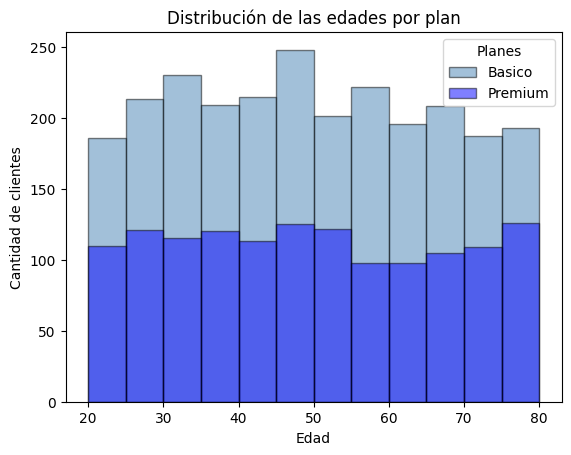

In [215]:
# Age Distribution of User Base
plans = user_profile['plan'].unique()
colors = {'Basico':'steelblue', 'Premium':'blue'}

for plan in plans:
    plt.hist(
        user_profile[user_profile['plan'] == plan]['age'],
        bins=12,
        range=(20,80),
        alpha=0.5,
        edgecolor='black',
        color=colors[plan],
        label=plan
    )

plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de las edades por plan')
plt.legend(title='Planes')
plt.show()

💡 Insights:
- The chart reveals an approximately symmetrical distribution with no single dominant peak. However, two significant user clusters are visible: one in the 45–50 age bracket and another in the 25–35 range. This suggests a potential market opportunity to expand customer acquisition strategies specifically targeting younger demographics to balance the user base.

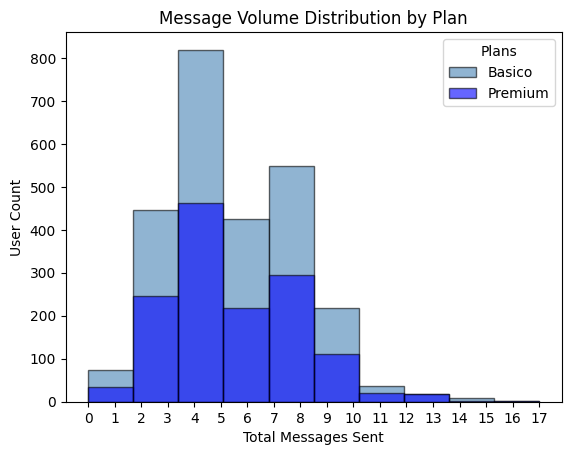

In [216]:
# Monthly Message Volume Distribution
colors = {'Basico':'steelblue', 'Premium':'blue'}

for plan in user_profile['plan'].unique():
    plt.hist(
        user_profile[user_profile['plan'] == plan]['message_count'],
        bins=10,
        range=(0,17),
        alpha=0.6,
        edgecolor='black',
        label=plan,
        color=colors[plan]
    )

plt.xticks(range(0,18))
plt.xlabel('Total Messages Sent')
plt.ylabel('User Count')
plt.title('Message Volume Distribution by Plan')
plt.legend(title='Plans')
plt.show()

💡 Insights:
- The chart shows a right-skewed distribution, indicating that the majority of users send between 3 and 5 messages per month. However, a small segment of power users displays intensive messaging behavior. The relatively low messaging volume for the general user base may be attributed to the widespread use of alternative platforms like WhatsApp for daily communication.

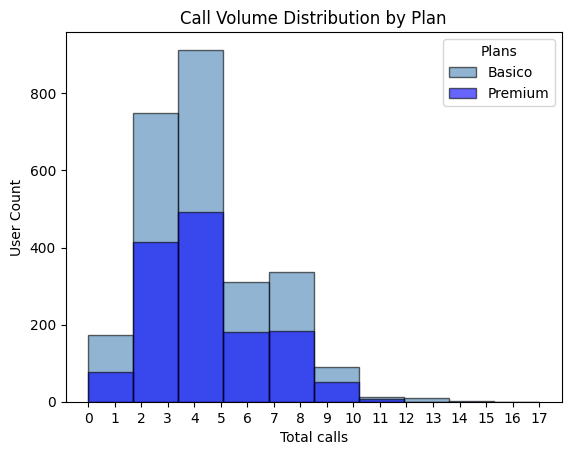

In [217]:
# Monthly Call Frequency Distribution
colors = {'Basico':'steelblue', 'Premium':'blue'}

for plan in user_profile['plan'].unique():
    plt.hist(
        user_profile[user_profile['plan'] == plan]['call_count'],
        bins=10,
        range=(0,17),
        alpha=0.6,
        edgecolor='black',
        label=plan,
        color=colors[plan]
    )

plt.xticks(range(0,18))
plt.xlabel('Total calls')
plt.ylabel('User Count')
plt.title('Call Volume Distribution by Plan')
plt.legend(title='Plans')
plt.show()

💡 Insights:
- Similar to the messaging data, the call volume shows a right-skewed distribution, indicating that the majority of customers exhibit low-to-moderate service usage. However, a small segment of power users demonstrates intensive call activity. This high-usage group represents a strategic opportunity for targeted upselling or premium service optimization to maximize revenue.

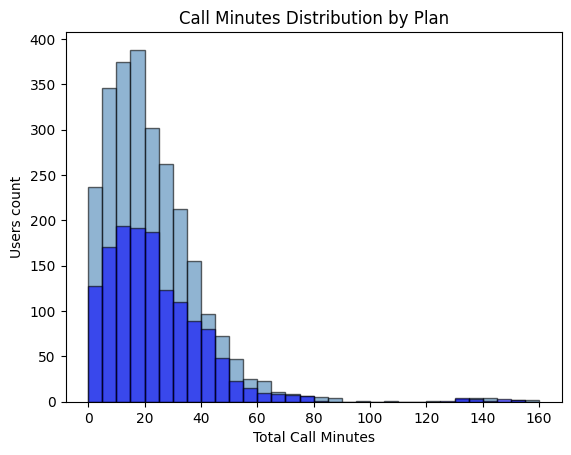

In [218]:
# Monthly Call Minutes Distribution
colors = {'Basico':'steelblue', 'Premium':'blue'}

for plan in user_profile['plan'].unique():
  plt.hist(
      user_profile[user_profile['plan'] == plan]['total_call_minutes'],
      bins=32,
      range=(0,160),
      alpha=0.6,
      color=colors[plan],
      label=plan,
      edgecolor='black'
)
plt.xticks(range(0,161,20))
plt.xlabel('Total Call Minutes')
plt.ylabel('Users count')
plt.title('Call Minutes Distribution by Plan')
plt.show()

💡 Insights:
- The distribution exhibits a pronounced positive skew, with the highest concentration of users between 5 and 20 minutes of call time. The long tail toward higher consumption levels likely represents our high-value customers—those who drive the most revenue. This data presents a significant opportunity to develop differentiated service plans and retention strategies specifically designed for high-engagement users.

### 5.2 Outlier Identification

**🎯 Objective:**
Detect extreme values (outliers) in key usage and customer variables that could potentially distort the analysis, and determine whether they require further cleaning, capping, or investigation.

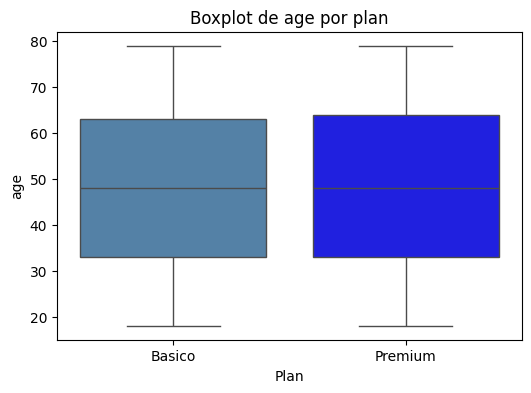

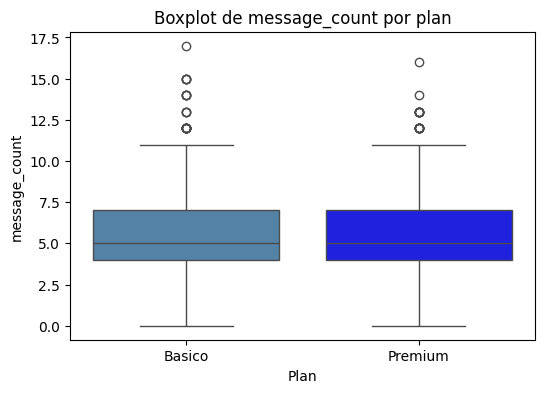

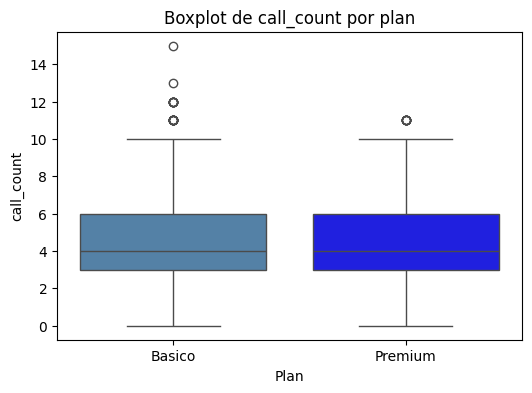

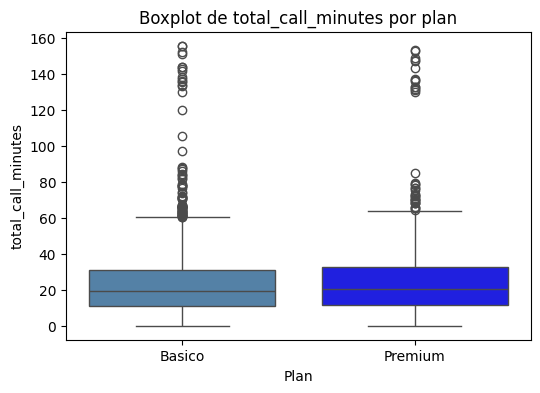

In [219]:
# Outlier Detection: Boxplot Analysis
columnas_numericas = ['age', 'message_count', 'call_count', 'total_call_minutes']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))

    sns.boxplot(
    data=user_profile,
    x='plan',
    y=col,
    hue='plan',
    palette={'Basico':'steelblue', 'Premium':'blue'},
    legend=False
)

    plt.title(f'Boxplot de {col} por plan')
    plt.xlabel('Plan')
    plt.ylabel(col)

    plt.show()

💡 Insights:
- `age`: The boxplot reveals a relatively symmetrical structure with a centered median and no visible outliers. This suggests a stable age distribution without extreme concentrations in any specific demographic.
- `message_count`: The data exhibits a positive skew with several outliers on the right side. This highlights a small but distinct segment of power users—a high-value group that could be targeted with tailored marketing campaigns.
- `call_count`: Similar to messaging, call frequency shows a right-skewed distribution with a few extreme values at the upper end. These represent a potential high-consumption segment that warrants further analysis for high-value classification.
- `total_call_minutes`: While most users cluster at the lower end (shorter call durations), there is a significant volume of outliers at the top. This intensive-usage segment likely drives a substantial portion of revenue. This presents a strategic opportunity for advanced customer segmentation and loyalty programs aimed at maximizing customer lifetime value (CLV).

In [220]:
# Statistical Outlier Detection: The IQR Method
outlier = {}
limit_columns = ['age', 'message_count', 'call_count', 'total_call_minutes']

for col in limit_columns:
    Q1 = user_profile[col].quantile(0.25)
    print('')
    print(f"📊 Analyzing column: {col}")
    print("-" * 50)
    print('First Cuartil', Q1)
    Q2 = user_profile[col].quantile(0.50)
    print('Second Cuartil', Q2)
    Q3 = user_profile[col].quantile(0.75)
    print('Therd Cuartil', Q3)
    IQR = Q3 - Q1
    print('IQR', IQR)
    limite_superior = (Q3 + 1.5 * IQR)
    print('Upper llimit', limite_superior)
    outlier[col] = user_profile[user_profile[col] > limite_superior]
    porcentaje = (len(outlier[col]) / len(user_profile)) * 100
    print(f"Outliers Users: {len(outlier[col])} ({porcentaje:.2f}%)")
    if len(outlier[col]) > 0:
        print()
        print('Characterizing users with extreme values in:', col)
        print(outlier[col][col].describe())


📊 Analyzing column: age
--------------------------------------------------
First Cuartil 33.0
Second Cuartil 48.0
Therd Cuartil 63.0
IQR 30.0
Upper llimit 108.0
Outliers Users: 0 (0.00%)

📊 Analyzing column: message_count
--------------------------------------------------
First Cuartil 4.0
Second Cuartil 5.0
Therd Cuartil 7.0
IQR 3.0
Upper llimit 11.5
Outliers Users: 46 (1.15%)

Characterizing users with extreme values in: message_count
count    46.000000
mean     12.891304
std       1.251280
min      12.000000
25%      12.000000
50%      12.000000
75%      13.000000
max      17.000000
Name: message_count, dtype: float64

📊 Analyzing column: call_count
--------------------------------------------------
First Cuartil 3.0
Second Cuartil 4.0
Therd Cuartil 6.0
IQR 3.0
Upper llimit 10.5
Outliers Users: 30 (0.75%)

Characterizing users with extreme values in: call_count
count    30.000000
mean     11.466667
std       0.860366
min      11.000000
25%      11.000000
50%      11.000000
75%     

In [221]:
# Outlier Treatment Strategy: Evaluating Thresholds vs. Maximum Values
user_profile[limit_columns].describe()

,age,message_count,call_count,total_call_minutes
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡 Insights & Outlier Treatment Strategy:
- `message_count` (message_count): Outliers will be retained. These values represent realistic usage patterns rather than data errors. Since they account for only 1.5% of the dataset, they do not significantly distort the overall statistics.
- `call_count` (call_count): Outliers will also be retained. Similar to messaging, these counts are plausible for high-usage customers. Given they represent only 0.75% of the data, their impact on statistical reliability is negligible.
- `total_call_minutes` (total_minutes): In this case, retaining outliers is not recommended. These values are exceptionally high and represent nearly 3% of the records, which could skew future modeling.
Action: I will apply Winsorization, capping these extreme values at the Upper Bound.
Strategic Note: While capped for statistical purposes, this specific group remains a high-priority segment for loyalty programs and targeted marketing.

In [222]:
# Data Treatment: Winsorization of `total_call_minutes`

Upper_limit = user_profile['total_call_minutes'].quantile(0.97)
user_profile['total_call_minutes_winsor'] = np.clip(user_profile['total_call_minutes'],
                                    a_min=None,
                                    a_max=limite_superior)
print("BEFORE Winsorization:")
print(user_profile['total_call_minutes'].describe())
print("\nAFTER Winsorization:")
print(user_profile['total_call_minutes_winsor'].describe())

BEFORE Winsorization:
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: total_call_minutes, dtype: float64

AFTER Winsorization:
count    3999.000000
mean       22.532895
std        14.790722
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max        61.857500
Name: total_call_minutes_winsor, dtype: float64


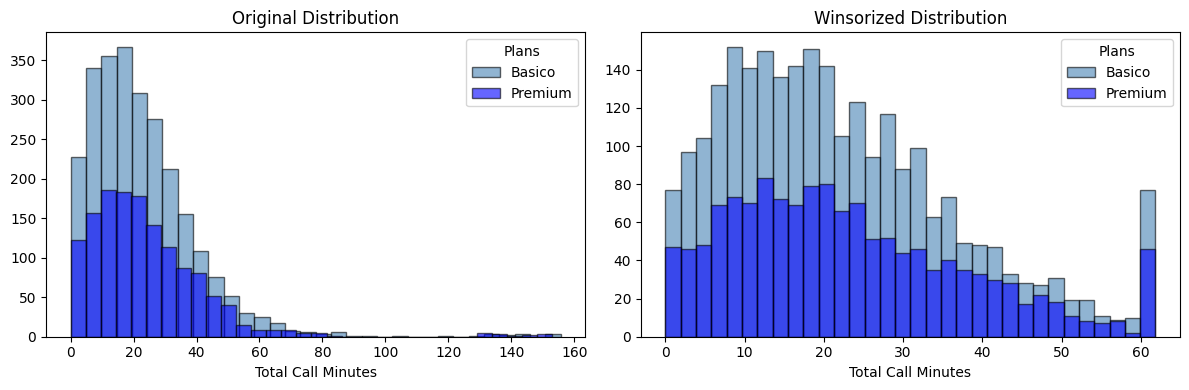

In [223]:
colors = {'Basico':'steelblue', 'Premium':'blue'}

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# -------- Original --------
for plan in user_profile['plan'].unique():
    axes[0].hist(
        user_profile[user_profile['plan']==plan]['total_call_minutes'],
        bins=32,
        alpha=0.6,
        edgecolor='black',
        label=plan,
        color=colors[plan]
    )

axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Total Call Minutes')
axes[0].legend(title='Plans')

# -------- Winsorizada --------
for plan in user_profile['plan'].unique():
    axes[1].hist(
        user_profile[user_profile['plan']==plan]['total_call_minutes_winsor'],
        bins=32,
        alpha=0.6,
        edgecolor='black',
        label=plan,
        color=colors[plan]
    )

axes[1].set_title('Winsorized Distribution')
axes[1].set_xlabel('Total Call Minutes')
axes[1].legend(title='Plans')

plt.tight_layout()
plt.show()

---

## 🧩 Step 6: Customer Segmentation

### 6.1 Usage-Based Segmentation
**🎯 Objective:**
Classify each user into specific usage tiers (Low Usage, Medium Usage, High Usage) based on their total call and message volume.

In [224]:
# Generating usage_group column based on activity thresholds
user_profile['usage_group']= np.where(
    (user_profile['call_count'] < 5) & (user_profile['message_count'] <5), 'Low Usage',
        np.where((user_profile['call_count'] < 10) & (user_profile['message_count'] <10), 'Medium Usage', 'High Usage')
)

In [225]:
# Data Transformation Validation
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,message_count,call_count,total_call_minutes,total_call_minutes_winsor,usage_group
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,23.70,Medium Usage
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,33.18,High Usage
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,10.74,Medium Usage
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,8.99,High Usage
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,8.01,Low Usage


### 6.2 Demographic Segmentation by Age
**🎯 Objective:**
Classify each user into specific age brackets to analyze behavioral patterns across different generations.

In [226]:
# Creating age_group
user_profile['age_group']= np.where(
    (user_profile['age'] < 30), 'Young',
        np.where((user_profile['age'] < 60), 'Adult', 'Senior')
)

In [227]:
# Data Transformation Validation
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,message_count,call_count,total_call_minutes,total_call_minutes_winsor,usage_group,age_group
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,23.70,Medium Usage,Adult
1,10001,Mateo,Torres,53,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,33.18,High Usage,Adult
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,10.74,Medium Usage,Adult
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,8.99,High Usage,Senior
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,8.01,Low Usage,Senior


### 6.3 Segment Visualization and Profile Analysis
**🎯 Objective:**
Visualize the distribution of users within the newly created segments (usage_group and age_group) to understand the overall composition of our customer base.

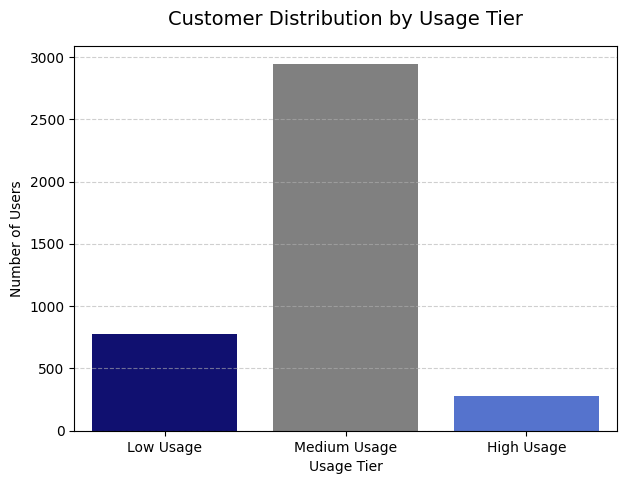

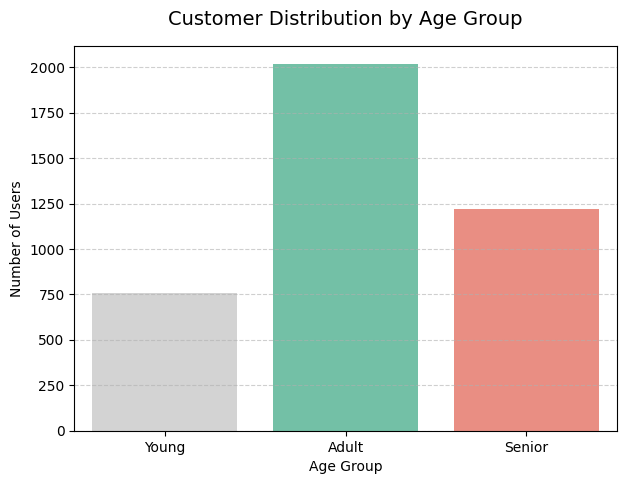

In [228]:
# Visualizing the distribution of usage groups

usage_order = ['Low Usage', 'Medium Usage', 'High Usage']
usage_colors = ['gray', 'royalblue', 'navy']

plt.figure(figsize=(7, 5))
sns.countplot(data=user_profile, x='usage_group', order=usage_order,
              palette=usage_colors, hue='usage_group', legend=False)

plt.title('Customer Distribution by Usage Tier', fontsize=14, pad=15)
plt.xlabel('Usage Tier')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Visualizing age segment frequency
age_order = ['Young', 'Adult', 'Senior']
age_colors = ['mediumaquamarine', 'salmon', 'lightgray']

plt.figure(figsize=(7, 5))
sns.countplot(data=user_profile, x='age_group', order=age_order,
              palette=age_colors, hue='age_group', legend=False)

plt.title('Customer Distribution by Age Group', fontsize=14, pad=15)
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###📑 Executive Summary

⚠️ **Data Quality & Integrity Issues**

The initial phase revealed inconsistencies that required rigorous cleaning to prevent statistical bias:
- Data Standardization: All features were cast to their appropriate data types for precise computation.
- Geographic Inconsistencies: The city column contained 11.7% missing values (469 records) and "?" placeholders. These were standardized to nulls for accurate reporting.
- Sentinel Values: The age column contained "-999" placeholders, which were corrected using Median Imputation to preserve the distribution.
Missing Data Mechanism (MAR): A diagnostic check confirmed that nulls in duration (55.2%) and length (44.7%) are Missing At Random (MAR). They correlate directly with the service type: "text" records naturally have null duration, while "call" records have null text length.
- Outlier Management: We applied Winsorization to the call_minutes column. This statistical capping ensures that average consumption metrics are not inflated by extreme, atypical user behavior.

🔍 **Demographic Insights (Age & Location)**
ConnectaTel’s user profile shows a distinct distribution:
- Primary Demographics: The core user base is aged 30–50, with a dominant presence in major hubs like Bogotá (the highest frequency city).
- Plan Adoption: The Basic Plan is the market leader across all age brackets, accounting for 2,595 out of 4,000 analyzed users.

📊 Usage Segmentation & Behavior
We identified two clear consumption profiles based on service interaction:
- Messaging-Centric (Text): This is the high-frequency service with 22,092 records, significantly outperforming voice calls in volume.
- Voice-Centric (Call): While lower in frequency, voice usage shows higher variability in duration, requiring closer monitoring.
- Power Users (Outliers): Significant extreme usage was detected, including single calls lasting up to 120 minutes and messages exceeding 1,490 characters.

➡️ **Strategic Implications**
- Business Value: While Premium users drive higher margins, the Basic plan holds the massive volume of data. This represents a major Upselling opportunity for users consistently exceeding their plan limits.
- Operational Risk: Extreme usage patterns (2-hour calls) suggest a niche group using residential lines for commercial or professional purposes, which could impact network stability and profit margins for "unlimited" tiers.

💡 **Strategic Recommendations**
- Tier Optimization: Introduce a "Basic Plus" intermediate plan. A plan focused on higher SMS limits could capture the large segment currently stuck between Basic and Premium.
- Retention Strategy: Investigate the 11.7% of users with unknown locations. This "blind spot" may hide regional coverage issues that lead to Churn (customer cancellation).
- Real-Time Usage Alerts: Implement automated alerts for high-usage outliers. If a Basic user hits an extreme threshold, trigger an immediate promotional offer to migrate them to a higher-tier plan.